## Import

In [2]:
# import os
# import mne
# from mne import events_from_annotations, create_info, EpochsArray, concatenate_epochs, Epochs
# import json
# import pandas as pd
# from pathlib import Path
# import re
import matplotlib.pyplot as plt
import numpy as np
import warnings
# from collections import defaultdict
from notebook_utils import reload_classes, reload_data_classes
from eegkit import (
    BaseTaskDTO,
    TaskDTO,
    SubjectFilterDTO,
    FilterParamsDTO,
    EpochParamsDTO,
    PSDParamsDTO,
    TimeDomainParamsDTO,
    TableInfoDTO,
    EpochFullParamsDTO,
    EpochPSDParamsDTO,
)

warnings.filterwarnings("ignore", message=".*boundary.*data discontinuities.*")
warnings.filterwarnings("ignore", message="FigureCanvasAgg is non-interactive, and thus cannot be shown")

In [7]:
EEGSubjectData = reload_data_classes()
release = 1
data_dir = f'/mount/NAS-public-dataset/HBN-EEG/cmi_bids_R{release}'
subject_data = EEGSubjectData(data_dir)
s1 = SubjectFilterDTO(task="contrastChangeDetection", sex=None, age_range=(5, 6))
sf = subject_data.filter_subjects_by_dto(s1)

print(len(sf))
print(sf)

1
['sub-NDARGL800LDW']


### Load

In [17]:
confirmation = input("Type '1' to reload: ")

if confirmation.lower() == '1':
    EEGSubjectData = reload_data_classes()
    release = 1
    data_dir = f'/mount/NAS-public-dataset/HBN-EEG/cmi_bids_R{release}'
    subject_data = EEGSubjectData(data_dir)

In [13]:
EEGController, EEGUI, _ = reload_classes()
controller = EEGController(subject_data)
subject_model = controller.subject_model
visualizer = controller.visualizer

ValueError: not enough values to unpack (expected 3, got 2)

# Debug

In [ ]:
subjects = sorted(controller.list_subjects())
subject = subjects[0]
subject

'sub-NDARAC904DMU'

In [ ]:
task_keys = sorted(controller.list_tasks(subject))
for (i, item) in enumerate(task_keys):
    print(i, item)

0 ('DespicableMe', None)
1 ('DiaryOfAWimpyKid', None)
2 ('FunwithFractals', None)
3 ('RestingState', None)
4 ('ThePresent', None)
5 ('contrastChangeDetection', '1')
6 ('contrastChangeDetection', '2')
7 ('contrastChangeDetection', '3')
8 ('seqLearning8target', None)
9 ('surroundSupp', '1')
10 ('surroundSupp', '2')
11 ('symbolSearch', None)


In [ ]:
task, run = task_keys[9]
l_freq = 3.0
h_freq = 35.0
tmin = 0.0
tmax = 2.4

task_dto = TaskDTO(subject=subject, task=task, run=run)
filter_params = FilterParamsDTO(l_freq=l_freq, h_freq=h_freq)
epoch_params = EpochParamsDTO(l_freq=l_freq, h_freq=h_freq, tmin=tmin, tmax=tmax)

task_model = subject_model.get_task(task_dto)

visualizer.show_annotations(task_dto, filter_params)

{'PowerLineFrequency': 60,
 'TaskName': 'surroundSupp',
 'EEGChannelCount': 129,
 'EEGReference': 'Cz',
 'RecordingType': 'continuous',
 'RecordingDuration': 293.42,
 'SamplingFrequency': 500,
 'SoftwareFilters': 'n/a'}

In [ ]:
raw = task_model.get_filtered_raw(filter_params)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 3 - 35 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 3.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 2.00 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 8.75 Hz (-6 dB cutoff frequency: 39.38 Hz)
- Filter length: 825 samples (1.650 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done  71 tasks      | elapsed:    1.0s


In [ ]:
epochs, labels = task_model.get_epochs(epoch_params)
sorted(labels)[:]

Not setting metadata
64 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 64 events and 1201 original time points ...
0 bad epochs dropped


['bg0_fg0.0_stim1',
 'bg0_fg0.0_stim2',
 'bg0_fg0.0_stim3',
 'bg0_fg0.0_stim3',
 'bg0_fg0.3_stim1',
 'bg0_fg0.3_stim1',
 'bg0_fg0.3_stim1',
 'bg0_fg0.3_stim2',
 'bg0_fg0.6_stim2',
 'bg0_fg0.6_stim2',
 'bg0_fg0.6_stim3',
 'bg0_fg0.6_stim3',
 'bg0_fg1.0_stim1',
 'bg0_fg1.0_stim2',
 'bg0_fg1.0_stim3',
 'bg0_fg1.0_stim3',
 'bg1_fg0.0_stim1',
 'bg1_fg0.0_stim1',
 'bg1_fg0.0_stim1',
 'bg1_fg0.0_stim1',
 'bg1_fg0.0_stim1',
 'bg1_fg0.0_stim1',
 'bg1_fg0.0_stim2',
 'bg1_fg0.0_stim2',
 'bg1_fg0.0_stim2',
 'bg1_fg0.0_stim3',
 'bg1_fg0.0_stim3',
 'bg1_fg0.0_stim3',
 'bg1_fg0.3_stim1',
 'bg1_fg0.3_stim1',
 'bg1_fg0.3_stim2',
 'bg1_fg0.3_stim2',
 'bg1_fg0.3_stim2',
 'bg1_fg0.3_stim2',
 'bg1_fg0.3_stim2',
 'bg1_fg0.3_stim2',
 'bg1_fg0.3_stim3',
 'bg1_fg0.3_stim3',
 'bg1_fg0.3_stim3',
 'bg1_fg0.3_stim3',
 'bg1_fg0.6_stim1',
 'bg1_fg0.6_stim1',
 'bg1_fg0.6_stim1',
 'bg1_fg0.6_stim1',
 'bg1_fg0.6_stim2',
 'bg1_fg0.6_stim2',
 'bg1_fg0.6_stim2',
 'bg1_fg0.6_stim3',
 'bg1_fg0.6_stim3',
 'bg1_fg0.6_stim3',


In [ ]:
epochs.tmin, epochs.tmax, epochs.info['sfreq'], epochs.get_data().shape

(0.0, 2.4, 500.0, (64, 128, 1201))

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


No projector specified for this dataset. Please consider the method self.add_proj.
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


[]

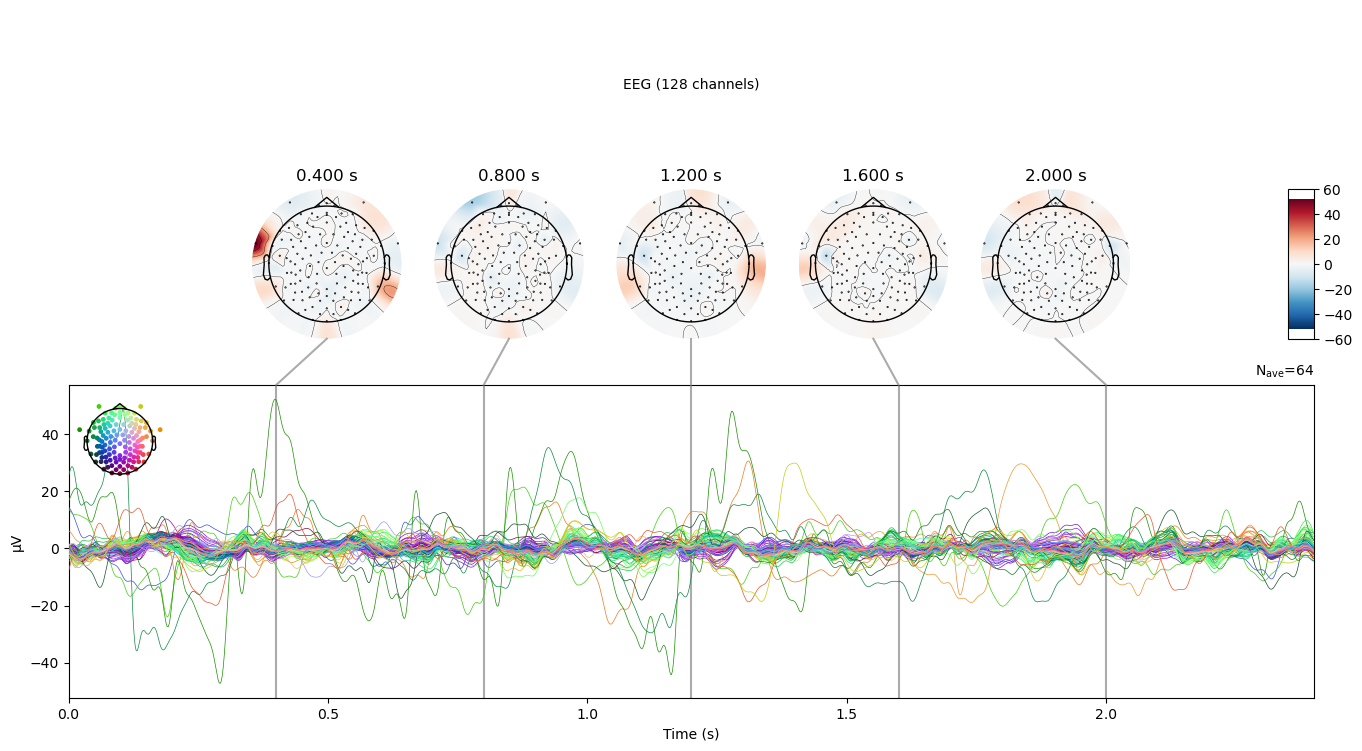

In [ ]:
evoked = epochs.average()
# evoked.plot()  # ERP waveform (time series)
times = times = np.arange(0.4, 2.4, 0.4)
# evoked.plot_topomap(times=times)  # Topographic maps
fig = evoked.plot_joint(times=times, show=False)  # Combines time series + topomap
fig.set_size_inches(15, 8)

if not isinstance(fig, plt.Figure):
    print("error")

plt.plot()

Effective window size : 4.096 (s)


[]

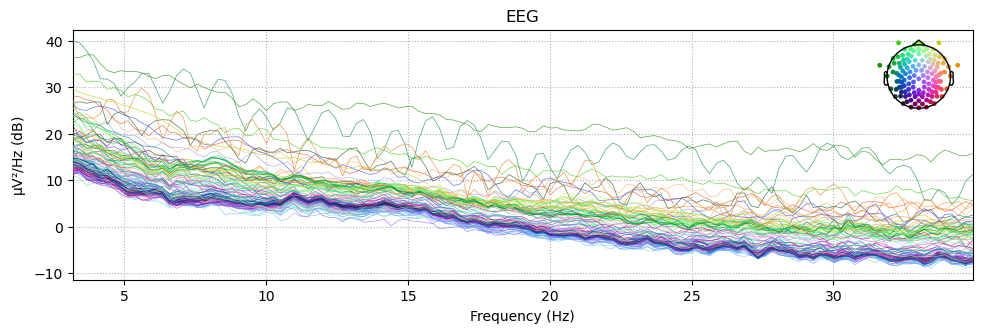

In [ ]:
psd = raw.compute_psd(fmin=3, fmax=35)
fig = psd.plot(show=False)
# fig.set_size_inches(15, 8)
plt.plot()

In [ ]:
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """Compute SNR spectrum from PSD spectrum using convolution.

    Parameters
    ----------
    psd : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Data object containing PSD values. Works with arrays as produced by
        MNE's PSD functions or channel/trial subsets.
    noise_n_neighbor_freqs : int
        Number of neighboring frequencies used to compute noise level.
        increment by one to add one frequency bin ON BOTH SIDES
    noise_skip_neighbor_freqs : int
        set this >=1 if you want to exclude the immediately neighboring
        frequency bins in noise level calculation

    Returns
    -------
    snr : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Array containing SNR for all epochs, channels, frequency bins.
        NaN for frequencies on the edges, that do not have enough neighbors on
        one side to calculate SNR.
    """
    # Construct a kernel that calculates the mean of the neighboring
    # frequencies
    averaging_kernel = np.concatenate(
        (
            np.ones(noise_n_neighbor_freqs),
            np.zeros(2 * noise_skip_neighbor_freqs + 1),
            np.ones(noise_n_neighbor_freqs),
        )
    )
    averaging_kernel /= averaging_kernel.sum()

    # Calculate the mean of the neighboring frequencies by convolving with the
    # averaging kernel.
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"), axis=-1, arr=psd
    )

    # The mean is not defined on the edges so we will pad it with nas. The
    # padding needs to be done for the last dimension only so we set it to
    # (0, 0) for the other ones.
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)

    return psd / mean_noise

In [ ]:
target_freq = 25
fmin = 1
fmax = 40

psd = epochs.compute_psd(fmin=fmin, fmax=fmax)
psds = psd.get_data()  # (n_epochs, n_channels, n_freqs)
freqs = psd.freqs  # (n_freqs,)

snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=1)

    Using multitaper spectrum estimation with 7 DPSS windows


[Text(0.5, 1.0, 'SNR spectrum'),
 Text(0.5, 0, 'Frequency [Hz]'),
 Text(0, 0.5, 'SNR'),
 (-2.0, 30.0),
 (1.0, 40.0)]

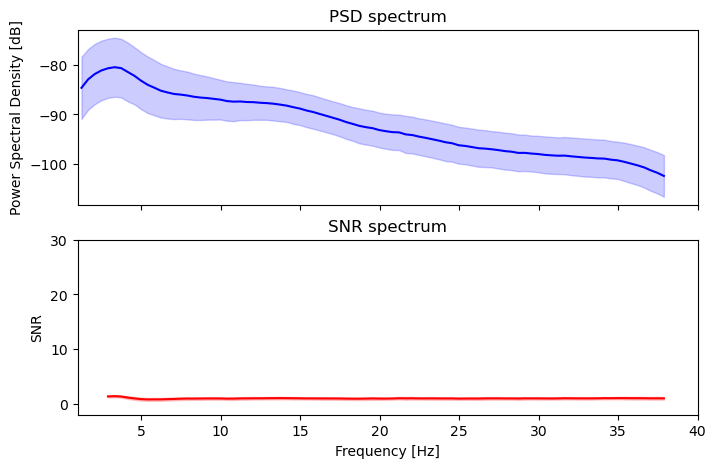

In [ ]:
fig, axes = plt.subplots(2, 1, sharex="all", sharey="none", figsize=(8, 5))
freq_range = range(
    np.where(np.floor(freqs) == 1.0)[0][0], np.where(np.ceil(freqs) == fmax - 1)[0][0]
)

psds_plot = 10 * np.log10(psds)
psds_mean = psds_plot.mean(axis=(0, 1))[freq_range]
psds_std = psds_plot.std(axis=(0, 1))[freq_range]
axes[0].plot(freqs[freq_range], psds_mean, color="b")
axes[0].fill_between(
    freqs[freq_range], psds_mean - psds_std, psds_mean + psds_std, color="b", alpha=0.2
)
axes[0].set(title="PSD spectrum", ylabel="Power Spectral Density [dB]")

# SNR spectrum
snr_mean = snrs.mean(axis=(0, 1))[freq_range]
snr_std = snrs.std(axis=(0, 1))[freq_range]

axes[1].plot(freqs[freq_range], snr_mean, color="r")
axes[1].fill_between(
    freqs[freq_range], snr_mean - snr_std, snr_mean + snr_std, color="r", alpha=0.2
)
axes[1].set(
    title="SNR spectrum",
    xlabel="Frequency [Hz]",
    ylabel="SNR",
    ylim=[-2, 30],
    xlim=[fmin, fmax],
)

In [ ]:
from pathlib import Path


def _repo_root(start: Path) -> Path:
    for p in [*start.parents, start]:
        if (p / ".git").exists() or (p / "pyproject.toml").exists():
            return p
    return start


_repo_root(Path.cwd())

PosixPath('/mount/NAS-workspace-portal/eeg2025-Vistec')

## Note

SSVP use welch (defalut by psd_compute)
SNR ()